<a href="https://colab.research.google.com/github/keysyaa26/ai-MyStudyBuddy-DataSet/blob/main/Preprocessing_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Proses preprocessing file_crawling_data.csv

# Import Library

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re


In [21]:
# import data
df = pd.read_csv('/content/drive/Shareddrives/My Study Buddy/Pembuatan AI/Dataset/file_summarize.csv')

df.head()

,Unnamed: 0,text,summary,source
0,0,"Jakarta , CNN Indonesia - - Dokter Ryan Thamri...",Dokter Lula Kamal yang merupakan selebriti sek...,indosum
1,1,Selfie ialah salah satu tema terpanas di kalan...,Asus memperkenalkan ZenFone generasi keempat...,indosum
2,2,"Jakarta , CNN Indonesia - - Dinas Pariwisata P...",Dinas Pariwisata Provinsi Bengkulu kembali men...,indosum
3,3,Merdeka.com - Indonesia Corruption Watch ( ICW...,Indonesia Corruption Watch ( ICW ) meminta Kom...,indosum
4,4,Merdeka.com - Presiden Joko Widodo ( Jokowi ) ...,Jokowi memimpin upacara penurunan bendera . Us...,indosum


# EDA

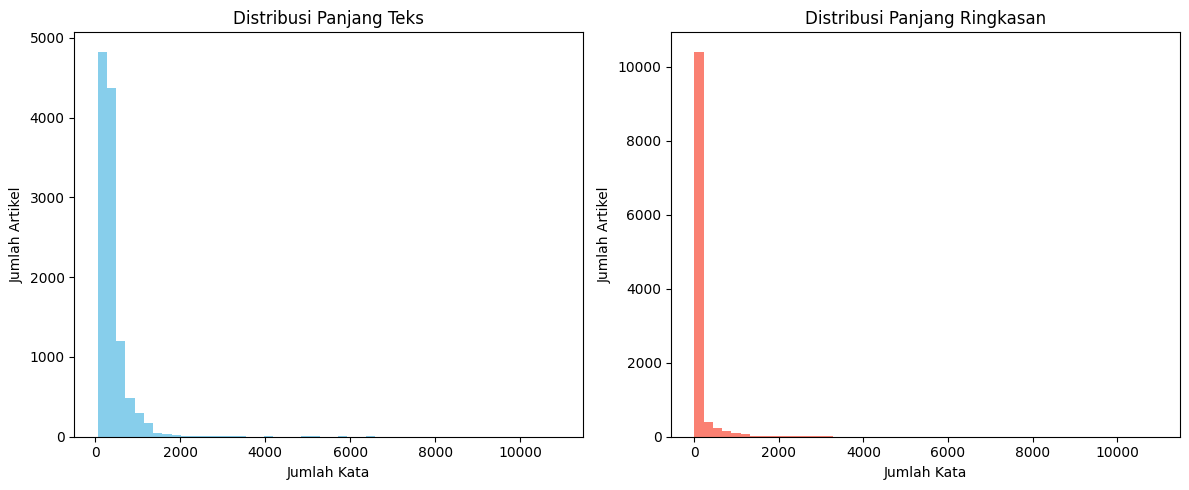

In [18]:
def length_data(data):
    data['text_length'] = data['text'].apply(lambda x: len(str(x).split()))
    data['summary_length'] = data['summary'].apply(lambda x: len(str(x).split()))

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.hist(data['text_length'], bins=50, color='skyblue')
    plt.title('Distribusi Panjang Teks')
    plt.xlabel('Jumlah Kata')
    plt.ylabel('Jumlah Artikel')

    plt.subplot(1, 2, 2)
    plt.hist(data['summary_length'], bins=50, color='salmon')
    plt.title('Distribusi Panjang Ringkasan')
    plt.xlabel('Jumlah Kata')
    plt.ylabel('Jumlah Artikel')

    plt.tight_layout()
    plt.show()

length_data(df)


# Cleaning

In [23]:
def clean_text(text, is_summary=False):
    text = str(text)

    # hapus tag HTML
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'\[.*?\]', ' ', text)
    text = re.sub(r'\{\{.*?\}\}', ' ', text)
    text = re.sub(r'\{.*?\}', ' ', text)

    # hapus URL
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # hapus ----
    if not is_summary:
        text = re.sub(r'^.*?[-–—]+\s*', '', text)

    # hapus karakter escape (\t, \r, \n)
    text = re.sub(r'[\t\r\n]', ' ', text)

    # hapus simbol berulang
    text = re.sub(r'(_+)', ' ', text)
    text = re.sub(r'(-{2,})', ' ', text)
    text = re.sub(r'(~+)', ' ', text)
    text = re.sub(r'(\+{2,})', ' ', text)
    text = re.sub(r'(\.{2,})', '. ', text) # Ubah titik banyak

    # hapus karakter selain huruf, angka, dan tanda baca dasar
    text = re.sub(r'[^a-zA-Z0-9.,!?\'"\- ]', ' ', text)

    # hapus spasi ganda yang dihasilkan dari proses regex di atas
    text = re.sub(r'\s+', ' ', text)

    # strip spasi di awal dan akhir
    return text.strip()


df['text_cleaned'] = df['text'].apply(lambda x: clean_text(x, is_summary=False))
df['summary_cleaned'] = df['summary'].apply(lambda x: clean_text(x, is_summary=True))

In [24]:
df['text'] = df['text'].apply(clean_text)
df['summary'] = df['summary'].apply(clean_text)

# hapus duplikat
df.drop_duplicates(subset=['text'], inplace=True)
print(f"Number of rows after removing text duplicates: {len(df)}")

# hapus kosong
df = df[df['text'].str.strip() != '']
print(f"Number of rows after removing empty text: {len(df)}")

print("\nData sesudah cleaning:")
df.head()

Number of rows after removing text duplicates: 11516
Number of rows after removing empty text: 11516

Data sesudah cleaning:


,Unnamed: 0,text,summary,source,text_cleaned,summary_cleaned
0,0,"- Dokter Ryan Thamrin , yang terkenal lewat ac...",Dokter Lula Kamal yang merupakan selebriti sek...,indosum,"- Dokter Ryan Thamrin , yang terkenal lewat ac...",Dokter Lula Kamal yang merupakan selebriti sek...
1,1,handset ini merupakan anggota keluarga ZenFone...,sama dibekali setup kamera ganda di depan . Me...,indosum,handset ini merupakan anggota keluarga ZenFone...,Asus memperkenalkan ZenFone generasi keempat d...
2,2,- Dinas Pariwisata Provinsi Bengkulu kembali m...,10 November 2017 yang lalu . Kegiatan yang ber...,indosum,- Dinas Pariwisata Provinsi Bengkulu kembali m...,Dinas Pariwisata Provinsi Bengkulu kembali men...
3,3,Indonesia Corruption Watch ICW meminta Komisi ...,"KTP , Johannes Marliem dan menjelaskan kepada ...",indosum,Indonesia Corruption Watch ICW meminta Komisi ...,Indonesia Corruption Watch ICW meminta Komisi ...
4,4,Presiden Joko Widodo Jokowi memimpin upacara p...,bagi sepeda kepada tamu undangan yang mengenak...,indosum,Presiden Joko Widodo Jokowi memimpin upacara p...,Jokowi memimpin upacara penurunan bendera . Us...


# Save Clean Data

In [25]:
df.to_csv('/content/drive/Shareddrives/My Study Buddy/Pembuatan AI/Dataset/file_summarize_clean.csv', index=False)